In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:

pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# zsq, 
#data_train = pd.read_csv("/content/drive/MyDrive/(mine)Deep Learning/data_train.csv")
#data_test = pd.read_csv("/content/drive/MyDrive/(mine)Deep Learning/data_val.csv")

# xyb, 
data_train = pd.read_csv("drive/MyDrive/Deep Learning Materials/Group Project/data_train.csv")
data_test = pd.read_csv("drive/MyDrive/Deep Learning Materials/Group Project/data_val.csv")
# google files
# df = pd.read_csv("data.csv")

In [ ]:
data_train=data_train.drop(columns=['Unnamed: 0'])
data_test=data_test.drop(columns=['Unnamed: 0'])

In [ ]:
data_train.head(5)

,temperature,age,income,Bar,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,destination_No Urgent Place,passanger_Friend,passanger_Kid,passanger_Partner,weather_Snowy,weather_Sunny,time_10PM,time_2PM,time_6PM,time_7AM,coupon_Carry out & Take away,coupon_Coffee House,coupon_Restaurant between 20 and 50,coupon_Restaurant less than 20,expiration_2h,gender_Male,maritalStatus_Married partner,maritalStatus_Single,maritalStatus_Unmarried partner,maritalStatus_Widowed,has_children_1,education_Bachelors degree,education_Graduate degree (Masters or Doctorate),education_High School Graduate,education_Some High School,education_Some college - no degree,occupation_Arts Design Entertainment Sports & Media,occupation_Building & Grounds Cleaning & Maintenance,occupation_Business & Financial,occupation_Community & Social Services,occupation_Computer & Mathematical,occupation_Construction & Extraction,occupation_Education&Training&Library,occupation_Farming Fishing & Forestry,occupation_Food Preparation & Serving Related,occupation_Healthcare Practitioners & Technical,occupation_Healthcare Support,occupation_Installation Maintenance & Repair,occupation_Legal,occupation_Life Physical Social Science,occupation_Management,occupation_Office & Administrative Support,occupation_Personal Care & Service,occupation_Production Occupations,occupation_Protective Service,occupation_Retired,occupation_Sales & Related,occupation_Student,occupation_Transportation & Material Moving,occupation_Unemployed,toCoupon_GEQ15min_1,toCoupon_GEQ25min_1,direction_same_1,Y
0,0.5,0.689655,0.214286,0.125,0.125,0.125,0.125,0.000,0,0,0,0,0,1,0,0,0,1,0,1,0,0,1,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,1,0,0
1,1.0,0.862069,0.214286,0.125,0.750,0.250,0.250,0.125,1,1,0,0,0,1,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
2,1.0,0.172414,1.000000,0.000,1.000,0.750,1.000,0.250,0,0,0,0,0,1,0,0,0,1,1,0,0,0,0,0,1,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,1,0,1
3,1.0,0.689655,1.000000,0.125,0.250,0.250,1.000,0.000,1,1,0,0,0,1,0,0,1,0,0,0,0,1,1,1,1,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1
4,1.0,0.000000,0.214286,0.250,0.250,0.125,0.250,0.000,1,1,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1


In [ ]:
data_train.shape

(8696, 62)

In [ ]:
data_test.head()

,temperature,age,income,Bar,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,destination_No Urgent Place,passanger_Friend,passanger_Kid,passanger_Partner,weather_Snowy,weather_Sunny,time_10PM,time_2PM,time_6PM,time_7AM,coupon_Carry out & Take away,coupon_Coffee House,coupon_Restaurant between 20 and 50,coupon_Restaurant less than 20,expiration_2h,gender_Male,maritalStatus_Married partner,maritalStatus_Single,maritalStatus_Unmarried partner,maritalStatus_Widowed,has_children_1,education_Bachelors degree,education_Graduate degree (Masters or Doctorate),education_High School Graduate,education_Some High School,education_Some college - no degree,occupation_Arts Design Entertainment Sports & Media,occupation_Building & Grounds Cleaning & Maintenance,occupation_Business & Financial,occupation_Community & Social Services,occupation_Computer & Mathematical,occupation_Construction & Extraction,occupation_Education&Training&Library,occupation_Farming Fishing & Forestry,occupation_Food Preparation & Serving Related,occupation_Healthcare Practitioners & Technical,occupation_Healthcare Support,occupation_Installation Maintenance & Repair,occupation_Legal,occupation_Life Physical Social Science,occupation_Management,occupation_Office & Administrative Support,occupation_Personal Care & Service,occupation_Production Occupations,occupation_Protective Service,occupation_Retired,occupation_Sales & Related,occupation_Student,occupation_Transportation & Material Moving,occupation_Unemployed,toCoupon_GEQ15min_1,toCoupon_GEQ25min_1,direction_same_1,Y
0,1.0,0.000000,1.000000,0.125,0.250,0.250,0.250,0.125,0,0,0,0,0,1,1,0,0,0,0,0,0,1,1,1,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0
1,1.0,0.344828,0.071429,0.750,0.000,1.000,0.250,0.000,1,1,0,0,0,1,0,1,0,0,0,0,1,0,1,1,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0
2,1.0,0.344828,0.357143,0.250,0.250,0.750,0.250,0.125,1,1,0,0,0,1,0,0,0,0,0,1,0,0,1,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1
3,1.0,1.000000,0.500000,0.000,0.125,0.125,0.250,0.125,0,0,0,0,0,1,0,0,0,1,1,0,0,0,1,1,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,1
4,0.5,0.344828,0.357143,0.000,0.125,0.750,0.125,0.125,0,0,0,0,0,1,0,0,0,1,0,1,0,0,1,1,1,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,1


In [ ]:
data_test.shape

(2175, 62)

# Feature Selection

## Machine Learning method

### Creat Xand Y

In [ ]:
# in train data
X_train = data_train.drop(columns=['Y'], axis=1)
Y_train = data_train['Y']

# in test data
X_test = data_test.drop(columns=['Y'], axis=1)
Y_test = data_test['Y']

### XGBoost Classification on Feature

XGBoost is an open source library that provides a high-performance implementation of gradient boost decision trees (similar to the decision trees that we have learnt). It is a machine learning model that is able to perform prediction tasks regardless of Regression or Classification.

The key idea of Gradient Boosted Decision Trees is that they build a series of trees in which each tree is trained so that it attempts to correct the mistakes of the previous tree in the seroes.

To optimize the parameters used in the XGBoost modelling algorithm, we first tune the parameters - in which GridSearchCV was used to optimize the parameters to determine the values that impact the model in order to enable the algorithm to perform at its best. In this case, while we managed to get the optimal parameter values (for at least the more significant parameters), we commented off the code as it would take a decent amount of time to process.

In [ ]:
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import xgboost as xgb
from xgboost import plot_importance
from xgboost import plot_tree
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error

In [ ]:
#xgb
# Tuning the Parameters
# official site: https://xgboost.readthedocs.io/en/latest/parameter.html#
def my_xgb(feature_train,target_train,feature_test,target_test,seed=5240):

  # n_estimators-->max_depth and min_child_weight-->gamma-->subsample-->reg_alpha-->learning_rate

  # random seed   
  xgb0 = xgb.XGBClassifier(random_state=seed)
  
  xgb_param_grid1 = {'n_estimators':[25,50,100,200,400,800],}
  xgb_best = GridSearchCV(xgb0,param_grid = xgb_param_grid1,cv = 3,scoring="roc_auc",n_jobs= -1, verbose=100)
  xgb_best.fit(feature_train,target_train)
  
  xgb_param_grid2 = {'max_depth':[5,10,15,20,25],
              'min_child_weight':range(100,301,100)}
  xgb_best2 = GridSearchCV(xgb_best.best_estimator_,param_grid = xgb_param_grid2,cv = 3,scoring="roc_auc",n_jobs= -1, verbose=100)
  xgb_best2.fit(feature_train,target_train)
  
  xgb_param_grid3 = {'gamma':range(0,20,2)}
  xgb_best3 = GridSearchCV(xgb_best2.best_estimator_,param_grid = xgb_param_grid3,cv = 3,scoring="roc_auc",n_jobs= -1, verbose=100)
  xgb_best3.fit(feature_train,target_train)
  
  xgb_param_grid4 = {'subsample':[0.6,0.7,0.75,0.8,0.85,0.9]}
  xgb_best4 = GridSearchCV(xgb_best3.best_estimator_,param_grid = xgb_param_grid4,cv = 3,scoring="roc_auc",n_jobs= -1, verbose=100)
  xgb_best4.fit(feature_train,target_train)
  
  xgb_param_grid5 = {'learning_rate':[0.001,0.01,0.1,0.25]}
  xgb_best5 = GridSearchCV(xgb_best4.best_estimator_,param_grid = xgb_param_grid5,cv = 3,scoring="roc_auc",n_jobs= -1, verbose=100)
  xgb_best5.fit(feature_train,target_train)
  
  xgb_best_end=xgb_best5

  print(xgb_best_end.best_estimator_)
  print(xgb_best_end.best_params_,"  ","Score:",xgb_best_end.best_score_)
  y_predict = xgb_best_end.predict(feature_test)     # 进行预测
  y_prob = xgb_best_end.predict_proba(feature_test)     # 进行预测
  
  return xgb_best_end

In [ ]:
xgb1 = my_xgb(X_train,Y_train,X_test,Y_test,seed=5240)

'''
# Result:
Fitting 3 folds for each of 6 candidates, totalling 18 fits
Fitting 3 folds for each of 15 candidates, totalling 45 fits
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Fitting 3 folds for each of 6 candidates, totalling 18 fits
Fitting 3 folds for each of 4 candidates, totalling 12 fits
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=0, gpu_id=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.25, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=100, missing=nan, monotone_constraints=None,
              n_estimators=200, n_jobs=None, num_parallel_tree=None,
              predictor=None, random_state=5240, ...)
{'learning_rate': 0.25}    Score: 0.790758993538133
'''

Fitting 3 folds for each of 6 candidates, totalling 18 fits
Fitting 3 folds for each of 15 candidates, totalling 45 fits
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Fitting 3 folds for each of 6 candidates, totalling 18 fits
Fitting 3 folds for each of 4 candidates, totalling 12 fits
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=0, gpu_id=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.25, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=100, missing=nan, monotone_constraints=None,
              n_estimators=200, n_jobs=None, num_parallel_tree=None,
       

"\n# Result:\nFitting 3 folds for each of 6 candidates, totalling 18 fits\nFitting 3 folds for each of 15 candidates, totalling 45 fits\nFitting 3 folds for each of 10 candidates, totalling 30 fits\nFitting 3 folds for each of 6 candidates, totalling 18 fits\nFitting 3 folds for each of 4 candidates, totalling 12 fits\nXGBClassifier(base_score=None, booster=None, callbacks=None,\n              colsample_bylevel=None, colsample_bynode=None,\n              colsample_bytree=None, early_stopping_rounds=None,\n              enable_categorical=False, eval_metric=None, feature_types=None,\n              gamma=0, gpu_id=None, grow_policy=None, importance_type=None,\n              interaction_constraints=None, learning_rate=0.25, max_bin=None,\n              max_cat_threshold=None, max_cat_to_onehot=None,\n              max_delta_step=None, max_depth=5, max_leaves=None,\n              min_child_weight=100, missing=nan, monotone_constraints=None,\n              n_estimators=200, n_jobs=None, num

In [ ]:
best_estimator = xgb1.best_estimator_
best_estimator

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=0, gpu_id=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.25, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=100, missing=nan, monotone_constraints=None,
              n_estimators=200, n_jobs=None, num_parallel_tree=None,
              predictor=None, random_state=5240, ...)

In [ ]:
# Copy the best XGBClassifier esimator in order to save time
best_xgb = xgb.XGBClassifier(gamma=0,learning_rate=0.25,max_depth=5,min_child_weight=100,n_estimators=200,random_state=5240)

Importance provides a score that indicates how useful or valuable each feature was in the construction of the boosted decision trees within the model. The more a variable is used to make key decisions with decision trees, the higher its relative importance.

As such, feature importance can be used to interpret our data to understand the most important features that define our predictions. In this case, looking at the table above, the predictor variable that is associated with a higher number means that the variable has a higher importance in the XGBoost Classification Model.

In [ ]:
def fit_best_xgb(XGB_Classifier,X_train,Y_train,X_test,Y_test):
  # Fitting and Training the model for Train & Test sets

  xgb_clf = XGB_Classifier

  xgb_clf.fit(X_train,Y_train)

  # Predicting using the model
  trainPredictin_xgb_clf = xgb_clf.predict(X_train)
  testPredictin_xgb_clf = xgb_clf.predict(X_test)

  # Evaluation in test set
  mse_model=mean_squared_error(Y_test, testPredictin_xgb_clf)
  r2_model=r2_score(Y_test, testPredictin_xgb_clf)
  # Evaluation in train seet
  r2_model_train=r2_score(Y_train, trainPredictin_xgb_clf)
  print('In train set, r2_model_train: ',round(r2_model_train,3))
  print('In test set, r2_model: ',round(r2_model,3),' ,mse_model: ',round(mse_model,3))

  # Weightage/Importance of each variable 
  ft_weights_xgb_clf = pd.DataFrame(xgb_clf.feature_importances_, columns=['weight'], index=X_train.columns)
  ft_weights_xgb_clf.sort_values('weight',inplace=True, ascending=False)
  
  return xgb_clf,ft_weights_xgb_clf

def myplot_feature_importance(ft_weights_xgb_clf):
  # Plotting feature importances without 0 value
  w=ft_weights_xgb_clf
  w=w.loc[w.weight!=0]

  plt.figure(figsize=(10,10))
  plt.barh(w.index, w.weight, align='center') 
  plt.title("Feature importances in the XGBoost Classification model", fontsize=14)
  plt.xlabel("Feature importance")
  plt.margins(y=0.001)
  # plt.xlim(0.001, 0.15)
  plt.show()

def myplot_feature_importance0(ft_weights_xgb_clf):
  # Plotting feature importances without 0 value
  w=ft_weights_xgb_clf
  # w=w.loc[w.weight!=0]

  plt.figure(figsize=(10,10))
  plt.barh(w.index, w.weight, align='center') 
  plt.title("Feature importances in the XGBoost Classification model", fontsize=14)
  plt.xlabel("Feature importance")
  plt.margins(y=0.001)
  # plt.xlim(0.001, 0.15)
  plt.show()

In [ ]:
xgb_clf,ft_weights_xgb_clf = fit_best_xgb(best_xgb, X_train=X_train, Y_train=Y_train, X_test=X_test, Y_test=Y_test)

In train set, r2_model_train:  0.117
In test set, r2_model:  -0.039  ,mse_model:  0.256


In [ ]:
ft_weights_xgb_clf.T

,coupon_Restaurant less than 20,coupon_Carry out & Take away,expiration_2h,passanger_Friend,destination_No Urgent Place,CoffeeHouse,coupon_Coffee House,direction_same_1,toCoupon_GEQ15min_1,weather_Sunny,time_6PM,passanger_Kid,time_7AM,maritalStatus_Married partner,Bar,education_Graduate degree (Masters or Doctorate),maritalStatus_Unmarried partner,Restaurant20To50,maritalStatus_Single,education_Some college - no degree,coupon_Restaurant between 20 and 50,education_Bachelors degree,CarryAway,income,gender_Male,time_2PM,age,has_children_1,occupation_Unemployed,occupation_Student,RestaurantLessThan20,time_10PM,occupation_Computer & Mathematical,passanger_Partner,temperature,occupation_Sales & Related,occupation_Education&Training&Library,weather_Snowy,toCoupon_GEQ25min_1,education_High School Graduate,occupation_Management,occupation_Transportation & Material Moving,maritalStatus_Widowed,occupation_Retired,occupation_Protective Service,occupation_Production Occupations,occupation_Personal Care & Service,occupation_Office & Administrative Support,education_Some High School,occupation_Arts Design Entertainment Sports & Media,occupation_Legal,occupation_Installation Maintenance & Repair,occupation_Healthcare Support,occupation_Healthcare Practitioners & Technical,occupation_Food Preparation & Serving Related,occupation_Farming Fishing & Forestry,occupation_Construction & Extraction,occupation_Community & Social Services,occupation_Business & Financial,occupation_Building & Grounds Cleaning & Maintenance,occupation_Life Physical Social Science
weight,0.106635,0.088391,0.050301,0.048318,0.04466,0.043435,0.042788,0.038425,0.034723,0.034589,0.0332,0.0268,0.026494,0.025286,0.023614,0.023276,0.021241,0.019044,0.018103,0.017374,0.015973,0.015763,0.015698,0.015429,0.015339,0.014566,0.014498,0.013602,0.013083,0.012901,0.012363,0.010923,0.010697,0.009232,0.00917,0.007749,0.007451,0.006838,0.006535,0.003149,0.002343,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


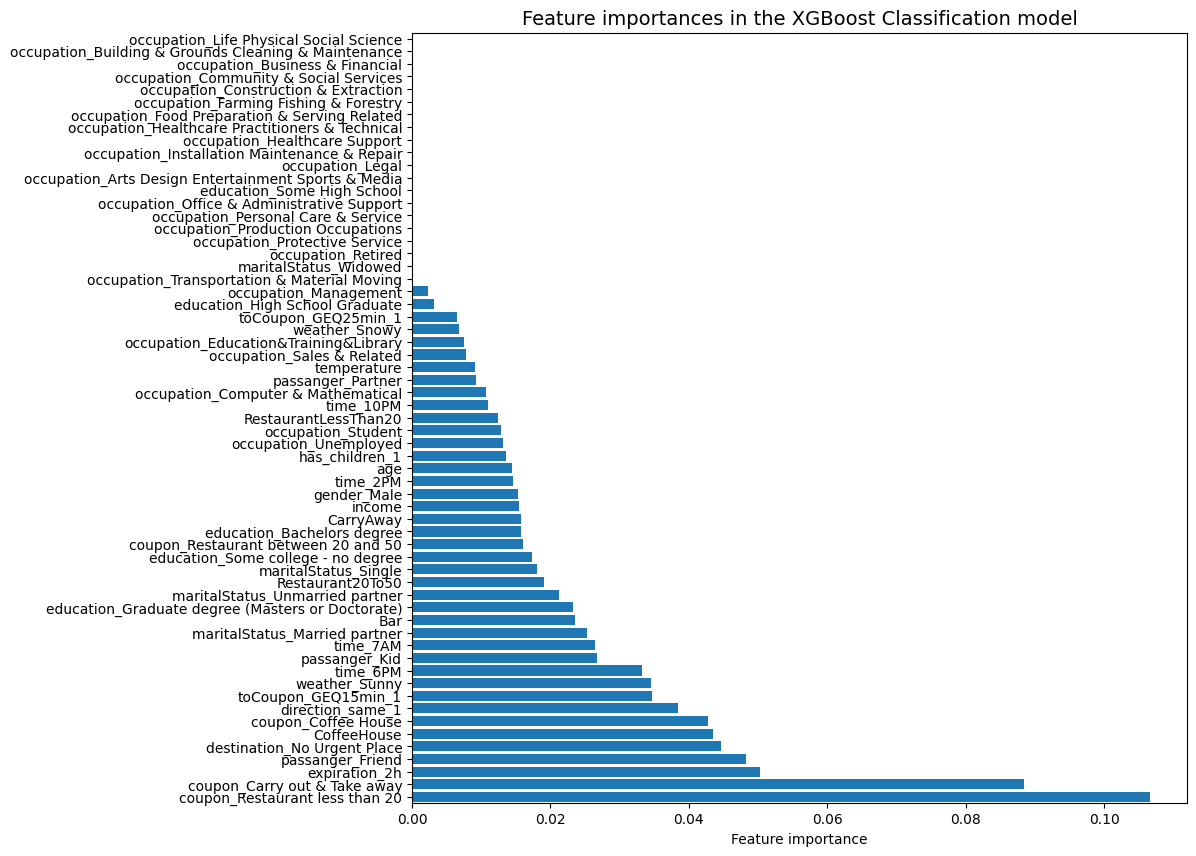

In [ ]:
myplot_feature_importance0(ft_weights_xgb_clf)

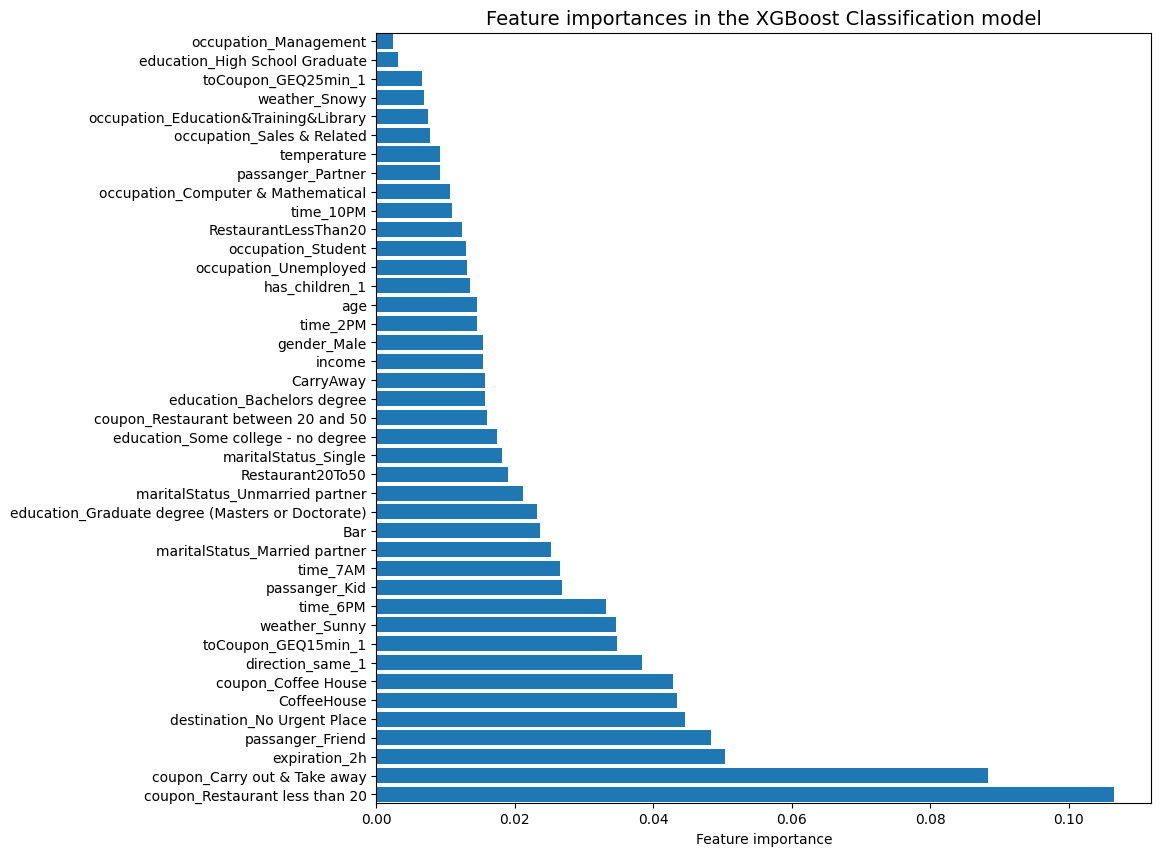

In [ ]:
myplot_feature_importance(ft_weights_xgb_clf)

In [ ]:
mask1 = (ft_weights_xgb_clf['weight']>0)
features_list = ft_weights_xgb_clf[mask1]
print('When weight>0, the number of features are ',features_list.shape[0])

mask2 = (ft_weights_xgb_clf['weight']==0)
drop_features_list = ft_weights_xgb_clf[mask2]
print('When weight==0, the number of features are ',drop_features_list.shape[0])

When weight>0, the number of features are  41
When weight==0, the number of features are  20


In [ ]:
features_list.T

,coupon_Restaurant less than 20,coupon_Carry out & Take away,expiration_2h,passanger_Friend,destination_No Urgent Place,CoffeeHouse,coupon_Coffee House,direction_same_1,toCoupon_GEQ15min_1,weather_Sunny,time_6PM,passanger_Kid,time_7AM,maritalStatus_Married partner,Bar,education_Graduate degree (Masters or Doctorate),maritalStatus_Unmarried partner,Restaurant20To50,maritalStatus_Single,education_Some college - no degree,coupon_Restaurant between 20 and 50,education_Bachelors degree,CarryAway,income,gender_Male,time_2PM,age,has_children_1,occupation_Unemployed,occupation_Student,RestaurantLessThan20,time_10PM,occupation_Computer & Mathematical,passanger_Partner,temperature,occupation_Sales & Related,occupation_Education&Training&Library,weather_Snowy,toCoupon_GEQ25min_1,education_High School Graduate,occupation_Management
weight,0.106635,0.088391,0.050301,0.048318,0.04466,0.043435,0.042788,0.038425,0.034723,0.034589,0.0332,0.0268,0.026494,0.025286,0.023614,0.023276,0.021241,0.019044,0.018103,0.017374,0.015973,0.015763,0.015698,0.015429,0.015339,0.014566,0.014498,0.013602,0.013083,0.012901,0.012363,0.010923,0.010697,0.009232,0.00917,0.007749,0.007451,0.006838,0.006535,0.003149,0.002343


In [ ]:
drop_features_list.T

,occupation_Transportation & Material Moving,maritalStatus_Widowed,occupation_Retired,occupation_Protective Service,occupation_Production Occupations,occupation_Personal Care & Service,occupation_Office & Administrative Support,education_Some High School,occupation_Arts Design Entertainment Sports & Media,occupation_Legal,occupation_Installation Maintenance & Repair,occupation_Healthcare Support,occupation_Healthcare Practitioners & Technical,occupation_Food Preparation & Serving Related,occupation_Farming Fishing & Forestry,occupation_Construction & Extraction,occupation_Community & Social Services,occupation_Business & Financial,occupation_Building & Grounds Cleaning & Maintenance,occupation_Life Physical Social Science
weight,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# *Export to csv file

In [ ]:
new_features_list=features_list.reset_index()
new_features_list.rename(columns={'index': 'feature name'}, inplace=True)
new_features_list

,feature name,weight
0,coupon_Restaurant less than 20,0.106635
1,coupon_Carry out & Take away,0.088391
2,expiration_2h,0.050301
3,passanger_Friend,0.048318
4,destination_No Urgent Place,0.044660
5,CoffeeHouse,0.043435
6,coupon_Coffee House,0.042788
7,direction_same_1,0.038425
8,toCoupon_GEQ15min_1,0.034723
9,weather_Sunny,0.034589


In [ ]:
new_features_list.to_csv('features_list_v2.csv')